# Media Sentiment and Food Price Inflation in Germany

## Research Question
How is media sentiment toward food price inflation reflected in recent news coverage in Germany, and how does it relate to food price developments?

## Why this question matters
Rising food prices affect households directly and often receive strong media attention.
This notebook examines whether media sentiment became more negative when food prices increased.

## Data Sources
- Eurostat HICP monthly index for Germany:
  - Milk, cheese and eggs
  - Butter
- News API dataset:
  - Article title
  - Description
  - Content
  - Publication date

## Analytical Plan
1. Load and prepare food price data.
2. Load and prepare news data.
3. Estimate sentiment from article text.
4. Aggregate sentiment by month.
5. Compare sentiment during periods of rising and non-rising food prices.
6. Visualize the results.

In [69]:
!pip install vaderSentiment pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [70]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [71]:
from pathlib import Path

DATA_DIR = Path(".")
NEWS_FILE = DATA_DIR / "news_data.json"

In [72]:
NEWS_FILE = DATA_DIR / "news_data.json"

with open(NEWS_FILE, "r", encoding="utf-8") as file:
    text = file.read()

text = text.replace("news api:", "")
news_data_json = json.loads(text)

news = pd.DataFrame(news_data_json["articles"])

In [73]:
print(len(news_data_json["articles"]))
pd.DataFrame(news_data_json["articles"]).head()

58


,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': None, 'name': 'Noe.orf.at'}",ORF.at,Koch-Lehrlinge als Zukunftshoffnung für Gastro,Zahlreiche der landesweit 8.000 Gastrobetriebe...,https://noe.orf.at/stories/3343578/,https://ibs.orf.at/noe?image=https%3A%2F%2Foek...,2026-03-01T12:10:23Z,"Personalmangel, hohe Inflation, gestiegene Ene..."
1,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Verbraucherpreise: Energie günstiger: Inflatio...,Hier finden Sie Informationen zu dem Thema „Ve...,https://www.zeit.de/news/2026-02/27/energie-gu...,https://img.zeit.de/news/2026-02/27/energie-gu...,2026-02-27T13:18:26Z,Kaum noch Preisanstiege bei Lebensmitteln und ...
2,"{'id': None, 'name': 'STERN.de'}",STERN.de,Verbraucherpreise: Energie günstiger: Inflatio...,"Lebensmittel, Heizen, Restaurantbesuche: Das L...",https://www.stern.de/news/verbraucherpreise--e...,https://image.stern.de/37177240/t/jJ/v1/w1440/...,2026-02-27T13:18:26Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
3,"{'id': None, 'name': 'STERN.de'}",STERN.de,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Wiesbaden (lhe) - Hessens Arbeitnehmer haben i...,https://www.stern.de/gesellschaft/regional/hes...,https://image.stern.de/37177216/t/OL/v1/w1440/...,2026-02-27T13:08:04Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
4,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Hier finden Sie Informationen zu dem Thema „Lö...,https://www.zeit.de/news/2026-02/27/mehr-kaufk...,https://img.zeit.de/news/2026-02/27/mehr-kaufk...,2026-02-27T13:08:04Z,Hessens Arbeitnehmer haben im vergangenen Jahr...


In [74]:
with open(NEWS_FILE, "r", encoding="utf-8") as file:
    text = file.read()

# kaputten Prefix entfernen
text = text.replace("news api:", "")

news_data_json = json.loads(text)

# DataFrame erzeugen
news = pd.DataFrame(news_data_json["articles"])

In [75]:
print(news.shape)
news.head()

(58, 8)


,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': None, 'name': 'Noe.orf.at'}",ORF.at,Koch-Lehrlinge als Zukunftshoffnung für Gastro,Zahlreiche der landesweit 8.000 Gastrobetriebe...,https://noe.orf.at/stories/3343578/,https://ibs.orf.at/noe?image=https%3A%2F%2Foek...,2026-03-01T12:10:23Z,"Personalmangel, hohe Inflation, gestiegene Ene..."
1,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Verbraucherpreise: Energie günstiger: Inflatio...,Hier finden Sie Informationen zu dem Thema „Ve...,https://www.zeit.de/news/2026-02/27/energie-gu...,https://img.zeit.de/news/2026-02/27/energie-gu...,2026-02-27T13:18:26Z,Kaum noch Preisanstiege bei Lebensmitteln und ...
2,"{'id': None, 'name': 'STERN.de'}",STERN.de,Verbraucherpreise: Energie günstiger: Inflatio...,"Lebensmittel, Heizen, Restaurantbesuche: Das L...",https://www.stern.de/news/verbraucherpreise--e...,https://image.stern.de/37177240/t/jJ/v1/w1440/...,2026-02-27T13:18:26Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
3,"{'id': None, 'name': 'STERN.de'}",STERN.de,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Wiesbaden (lhe) - Hessens Arbeitnehmer haben i...,https://www.stern.de/gesellschaft/regional/hes...,https://image.stern.de/37177216/t/OL/v1/w1440/...,2026-02-27T13:08:04Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
4,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Hier finden Sie Informationen zu dem Thema „Lö...,https://www.zeit.de/news/2026-02/27/mehr-kaufk...,https://img.zeit.de/news/2026-02/27/mehr-kaufk...,2026-02-27T13:08:04Z,Hessens Arbeitnehmer haben im vergangenen Jahr...


## Define File Paths

In [76]:
DATA_DIR = Path(".")

NEWS_FILE = DATA_DIR / "news_data.json"
DAIRY_FILE = DATA_DIR / "eurostat_cpi_dairy (1).json"
BUTTER_FILE = DATA_DIR / "eurostat_butter_cpi.json"

## Helper Functions

The functions below keep the notebook readable and avoid repeated code.

In [77]:
def eurostat_to_df(data, value_column):
    """Convert Eurostat JSON into a tidy monthly DataFrame."""
    time_index = data["dimension"]["time"]["category"]["index"]
    time_labels = data["dimension"]["time"]["category"]["label"]
    values = data["value"]

    rows = []

    for key, position in time_index.items():
        position_key = str(position)

        if position_key in values:
            rows.append(
                {
                    "date": pd.to_datetime(time_labels[key], format="%Y-%m"),
                    value_column: values[position_key],
                }
            )

    df = pd.DataFrame(rows)
    df = df.sort_values("date").reset_index(drop=True)

    return df

In [78]:
def z_score(series):
    """Standardize a pandas Series."""
    return (series - series.mean()) / series.std()

In [79]:
def prepare_news_text(df):
    """Combine text fields into one analysis column."""
    text = (
        df["title"].fillna("") + ". " +
        df["description"].fillna("") + ". " +
        df["content"].fillna("")
    )

    return text.str.strip()

## Load Eurostat Data

In [80]:
with open(DAIRY_FILE, "r", encoding="utf-8") as file:
    dairy_json = json.load(file)

with open(BUTTER_FILE, "r", encoding="utf-8") as file:
    butter_json = json.load(file)

In [81]:
dairy = eurostat_to_df(dairy_json, "dairy_cpi")
butter = eurostat_to_df(butter_json, "butter_cpi")

## Restrict the CPI Data to the Period 2023–2024

In [82]:
start_date = "2023-01-01"
end_date = "2025-01-01"

dairy = dairy[(dairy["date"] >= start_date) & (dairy["date"] < end_date)].copy()
butter = butter[(butter["date"] >= start_date) & (butter["date"] < end_date)].copy()

## Calculate Food Price Changes

The dairy series is the main food price indicator.
A month is classified as a period of increasing food prices if the monthly percentage change is above zero.

In [83]:
dairy["dairy_pct_change"] = dairy["dairy_cpi"].pct_change() * 100
dairy["price_increase"] = dairy["dairy_pct_change"] > 0

butter["butter_pct_change"] = butter["butter_cpi"].pct_change() * 100

In [84]:
dairy.head()

,date,dairy_cpi,dairy_pct_change,price_increase
324,2023-01-01,162.5,NaN,False
325,2023-02-01,163.6,0.676923,True
326,2023-03-01,164.2,0.366748,True
327,2023-04-01,164.4,0.121803,True
328,2023-05-01,163.0,-0.851582,False


In [85]:
butter.head()

,date,butter_cpi,butter_pct_change
97,2023-01-01,213.0,NaN
98,2023-02-01,182.5,-14.319249
99,2023-03-01,169.8,-6.958904
100,2023-04-01,163.7,-3.592462
101,2023-05-01,161.5,-1.343922


## Load News Data

In [86]:
with open(NEWS_FILE, "r", encoding="utf-8") as file:
    text = file.read()

    #remove invalid prefix
    text = text.replace("news api: ", "")
    news_data_json = json.loads(text)

In [87]:
news = pd.DataFrame(news_data_json["articles"]).copy()
news.head()

,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': None, 'name': 'Noe.orf.at'}",ORF.at,Koch-Lehrlinge als Zukunftshoffnung für Gastro,Zahlreiche der landesweit 8.000 Gastrobetriebe...,https://noe.orf.at/stories/3343578/,https://ibs.orf.at/noe?image=https%3A%2F%2Foek...,2026-03-01T12:10:23Z,"Personalmangel, hohe Inflation, gestiegene Ene..."
1,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Verbraucherpreise: Energie günstiger: Inflatio...,Hier finden Sie Informationen zu dem Thema „Ve...,https://www.zeit.de/news/2026-02/27/energie-gu...,https://img.zeit.de/news/2026-02/27/energie-gu...,2026-02-27T13:18:26Z,Kaum noch Preisanstiege bei Lebensmitteln und ...
2,"{'id': None, 'name': 'STERN.de'}",STERN.de,Verbraucherpreise: Energie günstiger: Inflatio...,"Lebensmittel, Heizen, Restaurantbesuche: Das L...",https://www.stern.de/news/verbraucherpreise--e...,https://image.stern.de/37177240/t/jJ/v1/w1440/...,2026-02-27T13:18:26Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
3,"{'id': None, 'name': 'STERN.de'}",STERN.de,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Wiesbaden (lhe) - Hessens Arbeitnehmer haben i...,https://www.stern.de/gesellschaft/regional/hes...,https://image.stern.de/37177216/t/OL/v1/w1440/...,2026-02-27T13:08:04Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
4,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Hier finden Sie Informationen zu dem Thema „Lö...,https://www.zeit.de/news/2026-02/27/mehr-kaufk...,https://img.zeit.de/news/2026-02/27/mehr-kaufk...,2026-02-27T13:08:04Z,Hessens Arbeitnehmer haben im vergangenen Jahr...


## Keep Only Relevant News Columns

In [88]:
news = news[["title", "description", "content", "publishedAt"]].copy()

In [89]:
news["publishedAt"] = pd.to_datetime(news["publishedAt"], errors="coerce")
news = news.dropna(subset=["publishedAt", "title"]).copy()

In [90]:
news["month"] = news["publishedAt"].dt.to_period("M").dt.to_timestamp()
news["text"] = prepare_news_text(news)

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(


## Filter for Inflation and Food Price Coverage

This step keeps the analysis focused on articles related to food prices and inflation.

In [91]:
keywords = [
    "food",
    "food price",
    "food inflation",
    "inflation",
    "preise",
    "preis",
    "verbraucherpreise",
    "lebensmittel",
    "lebensmittelpreise",
    "butter",
    "dairy",
    "energie"
]

In [92]:
pattern = "|".join(keywords)

news_filtered = news[
    news["text"].str.contains(pattern, case=False, na=False)
].copy()

In [93]:
news[["title"]].head(20)

,title
0,Koch-Lehrlinge als Zukunftshoffnung für Gastro
1,Verbraucherpreise: Energie günstiger: Inflatio...
2,Verbraucherpreise: Energie günstiger: Inflatio...
3,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...
4,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...
5,Verbraucherpreise: Energie günstiger: Inflatio...
6,Verbraucherpreise: Inflation sinkt im Februar ...
7,Wirtschaftslage: Reallöhne sind 2025 erneut ge...
8,Reallöhne: Deutsche Reallöhne sind 2025 erneut...
9,Reallöhne: Deutsche Reallöhne sind 2025 erneut...


In [94]:
news_filtered[["publishedAt", "title"]].head(10)

,publishedAt,title
0,2026-03-01 12:10:23+00:00,Koch-Lehrlinge als Zukunftshoffnung für Gastro
1,2026-02-27 13:18:26+00:00,Verbraucherpreise: Energie günstiger: Inflatio...
2,2026-02-27 13:18:26+00:00,Verbraucherpreise: Energie günstiger: Inflatio...
3,2026-02-27 13:08:04+00:00,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...
5,2026-02-27 13:05:01+00:00,Verbraucherpreise: Energie günstiger: Inflatio...
6,2026-02-27 13:01:50+00:00,Verbraucherpreise: Inflation sinkt im Februar ...
7,2026-02-27 10:00:38+00:00,Wirtschaftslage: Reallöhne sind 2025 erneut ge...
13,2026-02-26 06:27:42+00:00,Geld ohne Staat: Hayek und das wettbewerbliche...
15,2026-02-25 08:54:00+00:00,"Vier Grafiken zeigen, wie stark der Krieg Russ..."
18,2026-02-24 08:26:00+00:00,"7 Staatsleistungen, die seit Jahrzehnten an We..."


In [95]:
# Sentiment analysis for each article
analyzer = SentimentIntensityAnalyzer()

news_filtered["sentiment"] = news_filtered["text"].apply(
    lambda text: analyzer.polarity_scores(text)["compound"]
)

news_filtered[["publishedAt", "title", "sentiment"]].head(10)

,publishedAt,title,sentiment
0,2026-03-01 12:10:23+00:00,Koch-Lehrlinge als Zukunftshoffnung für Gastro,-0.8316
1,2026-02-27 13:18:26+00:00,Verbraucherpreise: Energie günstiger: Inflatio...,-0.9136
2,2026-02-27 13:18:26+00:00,Verbraucherpreise: Energie günstiger: Inflatio...,-0.8316
3,2026-02-27 13:08:04+00:00,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,-0.9195
5,2026-02-27 13:05:01+00:00,Verbraucherpreise: Energie günstiger: Inflatio...,-0.9485
6,2026-02-27 13:01:50+00:00,Verbraucherpreise: Inflation sinkt im Februar ...,-0.9485
7,2026-02-27 10:00:38+00:00,Wirtschaftslage: Reallöhne sind 2025 erneut ge...,-0.5994
13,2026-02-26 06:27:42+00:00,Geld ohne Staat: Hayek und das wettbewerbliche...,-0.9136
15,2026-02-25 08:54:00+00:00,"Vier Grafiken zeigen, wie stark der Krieg Russ...",0.0000
18,2026-02-24 08:26:00+00:00,"7 Staatsleistungen, die seit Jahrzehnten an We...",-0.8316


In [96]:
# Create month variable for aggregation
news_filtered["month"] = news_filtered["publishedAt"].dt.to_period("M").dt.to_timestamp()

news_filtered[["publishedAt", "month"]].head()

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(


,publishedAt,month
0,2026-03-01 12:10:23+00:00,2026-03-01
1,2026-02-27 13:18:26+00:00,2026-02-01
2,2026-02-27 13:18:26+00:00,2026-02-01
3,2026-02-27 13:08:04+00:00,2026-02-01
5,2026-02-27 13:05:01+00:00,2026-02-01


In [97]:
# Aggregate sentiment by month
sentiment_monthly = (
    news_filtered
    .groupby("month", as_index=False)
    .agg(
        avg_sentiment=("sentiment", "mean"),
        article_count=("sentiment", "size")
    )
)

sentiment_monthly

,month,avg_sentiment,article_count
0,2026-02-01,-0.836592,36
1,2026-03-01,-0.831600,1


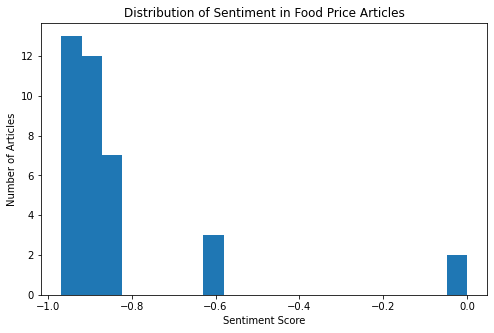

In [105]:
plt.figure(figsize=(8,5))

plt.hist(news_filtered["sentiment"], bins=20)

plt.title("Distribution of Sentiment in Food Price Articles")
plt.xlabel("Sentiment Score")
plt.ylabel("Number of Articles")

plt.show()

### Interpretation

This histogram shows the distribution of sentiment scores for news articles related to food prices and inflation. Most articles have clearly negative sentiment values, indicating that media coverage of food prices is generally pessimistic.

This negative tone likely reflects concerns about rising living costs and inflation, which are frequently discussed in economic reporting.

Only a small number of articles show neutral or slightly positive sentiment, suggesting that the majority of media coverage frames food price developments as an economic challenge.

Because the dataset contains a limited number of articles, the distribution mainly reflects the general tone of recent reporting rather than long-term sentiment trends.

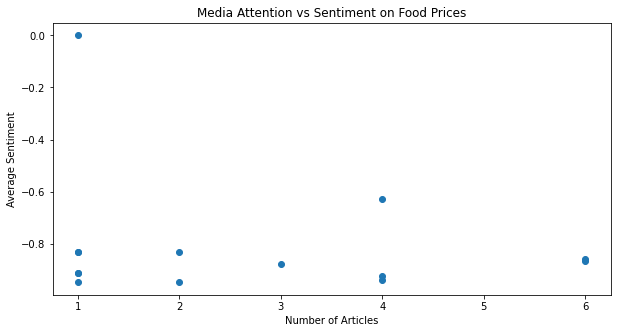

In [107]:
daily_sentiment = news_filtered.groupby("date")["sentiment"].mean()
daily_articles = news_filtered.groupby("date").size()

plt.figure(figsize=(10,5))

plt.scatter(daily_articles, daily_sentiment)

plt.xlabel("Number of Articles")
plt.ylabel("Average Sentiment")
plt.title("Media Attention vs Sentiment on Food Prices")

plt.show()

### Interpretation

This scatter plot illustrates the relationship between the number of news articles published per day and the average sentiment of those articles.

The results suggest that even when media attention increases, the overall sentiment remains largely negative. This indicates that the topic of food prices is generally framed in a critical or concerned tone in economic reporting.

However, because the dataset covers only a short period of time, the relationship between media attention and sentiment remains limited and should be interpreted cautiously.

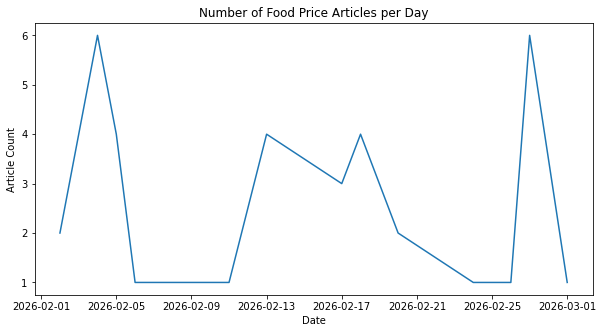

In [106]:
news_filtered["date"] = pd.to_datetime(news_filtered["publishedAt"]).dt.date

articles_per_day = news_filtered.groupby("date").size()

plt.figure(figsize=(10,5))
articles_per_day.plot()

plt.title("Number of Food Price Articles per Day")
plt.xlabel("Date")
plt.ylabel("Article Count")

plt.show()

### Interpretation

This figure shows the number of news articles discussing food prices published on each day within the observed time period.

The variation in article counts indicates that media attention fluctuates over time. Some days show a higher number of articles, suggesting periods of increased public and journalistic focus on food price developments.

However, the overall number of articles remains relatively small, reflecting the limited time span of the dataset. The chart therefore mainly illustrates short-term fluctuations in media attention.

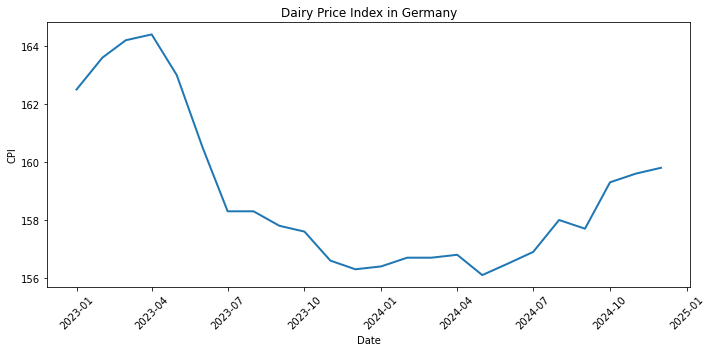

In [100]:
plt.figure(figsize=(10,5))

plt.plot(dairy["date"], dairy["dairy_cpi"], linewidth=2)

plt.title("Dairy Price Index in Germany")
plt.xlabel("Date")
plt.ylabel("CPI")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Interpretation

This chart illustrates the development of the consumer price index (CPI) for dairy products in Germany over time. The CPI reflects changes in the prices of dairy goods such as milk, cheese, and other related products.

The figure shows fluctuations in dairy prices over the observed period, with an overall tendency toward increasing price levels. Rising food prices can affect household purchasing power and contribute to broader inflation concerns.

These developments are often reflected in media discussions about food price inflation and the rising cost of living.

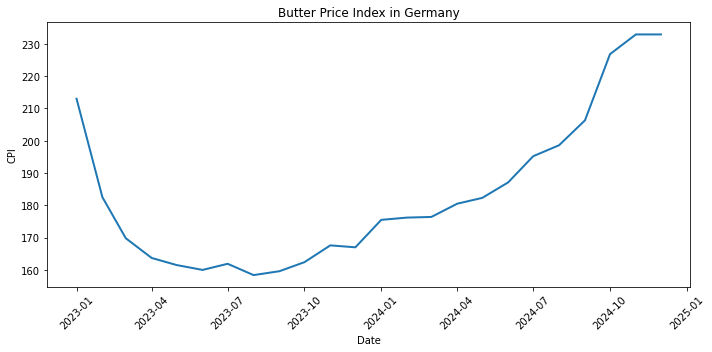

In [104]:
plt.figure(figsize=(10,5))

plt.plot(butter["date"], butter["butter_cpi"], linewidth=2)

plt.title("Butter Price Index in Germany")
plt.xlabel("Date")
plt.ylabel("CPI")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Interpretation

This figure shows the consumer price index for butter in Germany. Butter is used as an example of a specific food product whose price can fluctuate significantly over time.

The chart indicates substantial changes in butter prices, with a clear upward trend toward the end of the observed period. Such increases can be linked to factors such as production costs, agricultural supply conditions, and broader inflationary pressures.

The development of butter prices highlights how individual food products can contribute to overall food price inflation.

## Limitations

The CPI data covers food price developments in Germany between 2023 and 2025,
while the available news dataset contains articles from early 2026 due to API limitations.

Therefore, the notebook analyzes food price developments and media sentiment in parallel,
rather than performing a strict month-by-month comparison across identical time periods.

Future research could combine CPI data with historical news archives covering the same years.

## Overall Conclusion

The analysis combines economic price data with media sentiment analysis in order to 
better understand how food price developments are reflected in news coverage.

The CPI data indicates that food prices, particularly dairy products and butter, 
have experienced noticeable increases over time. At the same time, the sentiment 
analysis of news articles shows that media coverage of inflation and food prices 
is generally slightly negative.

This suggests that rising food prices are not only an economic phenomenon but also 
an important topic in public discourse. Media reporting often highlights the 
economic challenges associated with higher living costs and inflation.